# Laboratorio 07 - Aprendizaje No Supervisado

**Estudiante:** Erick Manuel Arancibia Flores

**Dataset:** EMNIST (Extended MNIST), variante Balanced - 131.600 imagenes 28x28 de caracteres manuscritos (letras + digitos), 47 clases balanceadas.


## Punto 1 - K-Means con generador aleatorio de centroides

### Generador de dataset

Modificamos el generador original para que produzca entre 1 y 20 centroides distribuidos aleatoriamente, pero garantizando una distancia mínima entre ellos. Así los grupos se ven bien separados al graficarlos y podemos verificar visualmente que K-Means funciona.

In [2]:
from sklearn.datasets import make_blobs
import numpy as np
import matplotlib.pyplot as plt

# Generador de centroides aleatorios entre 1 y 20, bien separados.
# Si quisieramos cambiar el rango, basta con modificar n_centros o min_dist.
# n_centros: numero de grupos a generar (entre 1 y 20)
# min_dist: distancia minima entre centroides para que se vean separados visualmente

def generar_centroides(n_centros, min_dist=4.0, rango=(-20, 20), max_intentos=5000, seed=42):
    rng = np.random.RandomState(seed)
    centros = []
    intentos = 0
    while len(centros) < n_centros and intentos < max_intentos:
        candidato = rng.uniform(rango[0], rango[1], size=2)
        if all(np.linalg.norm(candidato - c) >= min_dist for c in centros):
            centros.append(candidato)
        intentos += 1
    return np.array(centros)

# Cambiamos n_centros entre 1 y 20 para probar distintos escenarios
n_centros = 6
blob_centers = generar_centroides(n_centros, min_dist=5.0, seed=42)
blob_std = np.array([0.7] * len(blob_centers))

X, y = make_blobs(n_samples=2000, centers=blob_centers,
                  cluster_std=blob_std, random_state=42)

print("Cantidad de centroides generados:", len(blob_centers))
print("Centroides:")
print(blob_centers)

Cantidad de centroides generados: 6
Centroides:
[[ -5.01839525  18.02857226]
 [  9.27975767   3.94633937]
 [-13.75925438 -13.76021919]
 [-17.67665551  14.64704583]
 [  4.04460047   8.32290311]
 [ 13.29770563 -11.50643557]]


In [3]:
# Funcion para graficar los clusters (igual al cuadernillo original)
def plot_clusters(X, y=None):
    plt.scatter(X[:, 0], X[:, 1], c=y, s=1)
    plt.xlabel("$x_1$", fontsize=14)
    plt.ylabel("$x_2$", fontsize=14, rotation=0)

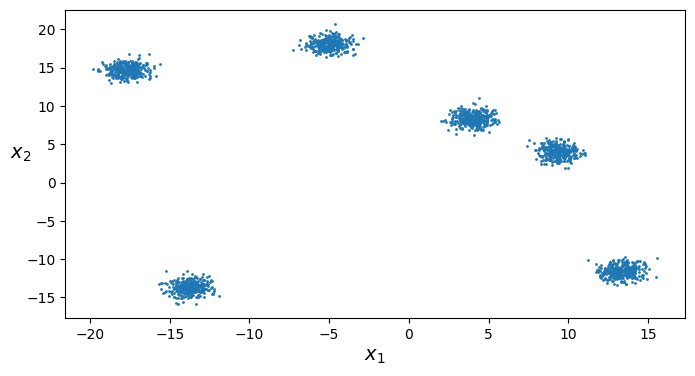

In [4]:
# Visualizacion del dataset generado sin etiquetas
plt.figure(figsize=(8, 4))
plot_clusters(X)
plt.show()

### Entrenamiento de K-Means

Aplicamos K-Means usando como `k` la misma cantidad de centroides que generamos, así verificamos que el modelo recupere los grupos reales.

In [5]:
from sklearn.cluster import KMeans

# Si quisieramos forzar otro k, basta con cambiar este valor.
# Lo dejamos igual al numero de centros generados para verificar que K-Means
# recupere correctamente los grupos.
k = len(blob_centers)
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
y_pred = kmeans.fit_predict(X)
y_pred

array([1, 4, 0, ..., 4, 1, 0], shape=(2000,), dtype=int32)

In [6]:
# Centroides aprendidos por el modelo
kmeans.cluster_centers_

array([[-13.74656823, -13.69385705],
       [  4.01294057,   8.3447371 ],
       [ 13.33269656, -11.55984301],
       [-17.70130657,  14.67457681],
       [ -5.02328588,  18.02657976],
       [  9.34013688,   4.0012892 ]])

In [7]:
# Probamos prediciendo a que cluster pertenecen algunas muestras nuevas
X_new = np.array([[0, 2], [3, 2], [-3, 3], [-3, 2.5]])
kmeans.predict(X_new)

array([1, 1, 1, 1], dtype=int32)

In [8]:
# Funciones para visualizar puntos, centroides y fronteras de decision (del cuadernillo original)
def plot_data(X):
    plt.plot(X[:, 0], X[:, 1], 'k.', markersize=2)

def plot_centroids(centroids, weights=None, circle_color='w', cross_color='k'):
    if weights is not None:
        centroids = centroids[weights > weights.max() / 10]
    plt.scatter(centroids[:, 0], centroids[:, 1],
                marker='o', s=10, linewidths=8,
                color=circle_color, zorder=10, alpha=0.9)
    plt.scatter(centroids[:, 0], centroids[:, 1],
                marker='x', s=2, linewidths=10,
                color=cross_color, zorder=11, alpha=1)

def plot_decision_boundaries(clusterer, X, resolution=1000, show_centroids=True,
                             show_xlabels=True, show_ylabels=True):
    mins = X.min(axis=0) - 0.1
    maxs = X.max(axis=0) + 0.1
    xx, yy = np.meshgrid(np.linspace(mins[0], maxs[0], resolution),
                         np.linspace(mins[1], maxs[1], resolution))
    Z = clusterer.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.contourf(Z, extent=(mins[0], maxs[0], mins[1], maxs[1]),
                cmap="Pastel2")
    plt.contour(Z, extent=(mins[0], maxs[0], mins[1], maxs[1]),
                linewidths=1, colors='k')
    plot_data(X)
    if show_centroids:
        plot_centroids(clusterer.cluster_centers_)

    if show_xlabels:
        plt.xlabel("$x_1$", fontsize=14)
    else:
        plt.tick_params(labelbottom=False)
    if show_ylabels:
        plt.ylabel("$x_2$", fontsize=14, rotation=0)
    else:
        plt.tick_params(labelleft=False)

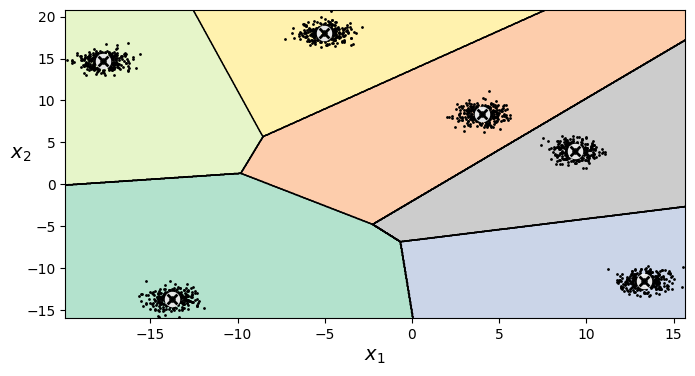

In [9]:
# Grafica de las fronteras de decision aprendidas
plt.figure(figsize=(8, 4))
plot_decision_boundaries(kmeans, X)
plt.show()

En lugar de asignar duro a cada muestra a un cluster (*hard clustering*), también se puede asignar una puntuación según la distancia al centroide (*soft clustering*).

In [10]:
# Distancias de cada muestra nueva a cada centroide
kmeans.transform(X_new)

array([[20.86301242,  7.50728852, 19.0165754 , 21.77110818, 16.79537614,
         9.5521367 ],
       [22.95091929,  6.42508657, 17.04798993, 24.2732155 , 17.92273347,
         6.64849563],
       [19.85380547,  8.81745712, 21.8802652 , 18.77296349, 15.16218272,
        12.38069297],
       [19.43527038,  9.1291997 , 21.55078102, 19.08792119, 15.65785313,
        12.43112415]])

### Iteraciones del algoritmo

K-Means parte de centroides iniciales y va recalculando hasta converger. Aquí mostramos las primeras iteraciones para ver el proceso paso a paso.

In [11]:
# Tres modelos con diferente numero de iteraciones para mostrar la evolucion
# Si quisieramos cambiar el comportamiento, podemos modificar init, n_init o algorithm
kmeans_iter1 = KMeans(n_clusters=k, init="k-means++", n_init=1,
                      algorithm="elkan", max_iter=3, random_state=4)
kmeans_iter2 = KMeans(n_clusters=k, init="k-means++", n_init=1,
                     algorithm="elkan", max_iter=2, random_state=1)
kmeans_iter3 = KMeans(n_clusters=k, init="k-means++", n_init=1,
                     algorithm="elkan", max_iter=3, random_state=5)
kmeans_iter1.fit(X)
kmeans_iter2.fit(X)
kmeans_iter3.fit(X)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",6
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",1
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",3
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",5
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'elkan'


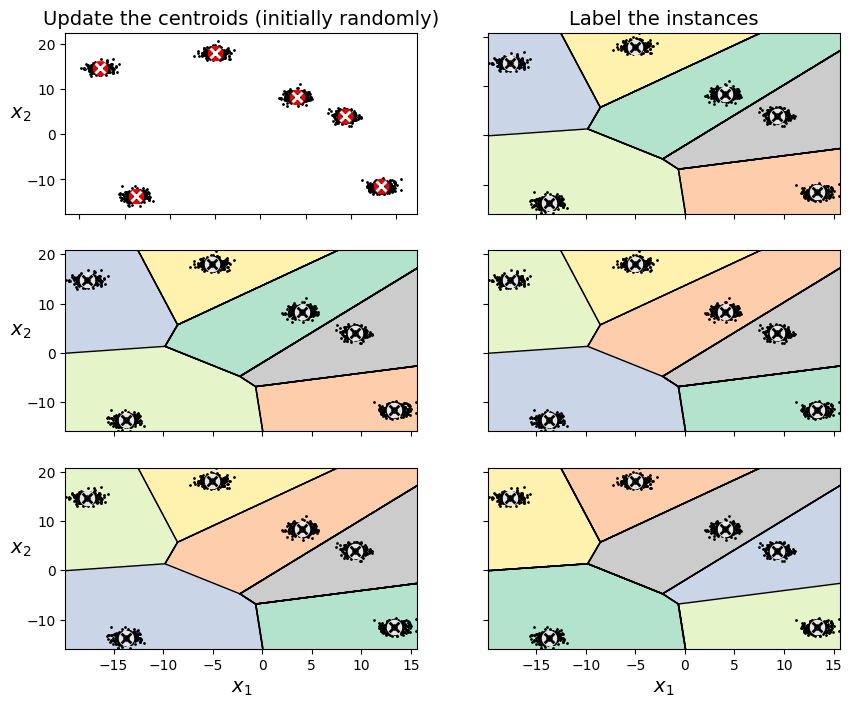

In [12]:
# Visualizacion de la evolucion del algoritmo a lo largo de las iteraciones
plt.figure(figsize=(10, 8))

plt.subplot(321)
plot_data(X)
plot_centroids(kmeans_iter1.cluster_centers_, circle_color='r', cross_color='w')
plt.ylabel("$x_2$", fontsize=14, rotation=0)
plt.tick_params(labelbottom=False)
plt.title("Update the centroids (initially randomly)", fontsize=14)

plt.subplot(322)
plot_decision_boundaries(kmeans_iter1, X, show_xlabels=False, show_ylabels=False)
plt.title("Label the instances", fontsize=14)

plt.subplot(323)
plot_decision_boundaries(kmeans_iter1, X, show_centroids=False, show_xlabels=False)
plot_centroids(kmeans_iter2.cluster_centers_)

plt.subplot(324)
plot_decision_boundaries(kmeans_iter2, X, show_xlabels=False, show_ylabels=False)

plt.subplot(325)
plot_decision_boundaries(kmeans_iter2, X, show_centroids=False)
plot_centroids(kmeans_iter3.cluster_centers_)

plt.subplot(326)
plot_decision_boundaries(kmeans_iter3, X, show_ylabels=False)

plt.show()

### Sensibilidad a la inicialización

Según el estado inicial, K-Means puede llegar a soluciones distintas. Comparamos dos inicializaciones diferentes.

In [13]:
def plot_clusterer_comparison(clusterer1, clusterer2, X, title1=None, title2=None):
    clusterer1.fit(X)
    clusterer2.fit(X)

    plt.figure(figsize=(10, 3.2))

    plt.subplot(121)
    plot_decision_boundaries(clusterer1, X)
    if title1:
        plt.title(title1, fontsize=14)

    plt.subplot(122)
    plot_decision_boundaries(clusterer2, X, show_ylabels=False)
    if title2:
        plt.title(title2, fontsize=14)

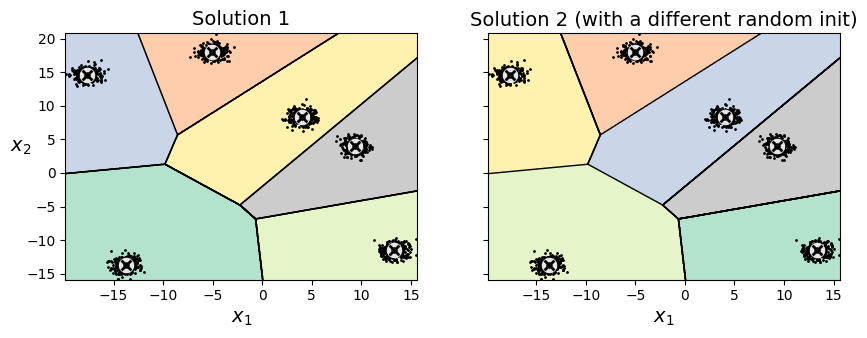

In [14]:
# Comparamos init aleatoria vs k-means++ (la inteligente que viene por defecto)
kmeans_rnd_init1 = KMeans(n_clusters=k, init="random", n_init=1,
                         algorithm="elkan", random_state=19)
kmeans_rnd_init2 = KMeans(n_clusters=k, init="k-means++", n_init=1,
                         algorithm="lloyd", random_state=19)

plot_clusterer_comparison(kmeans_rnd_init1, kmeans_rnd_init2, X,
                          "Solution 1", "Solution 2 (with a different random init)")
plt.show()

Para reducir el impacto de la inicialización, lanzamos varias corridas y nos quedamos con la mejor.

In [15]:
# Corremos 10 inicializaciones aleatorias y se queda con la de menor inercia
kmeans_rnd_10_inits = KMeans(n_clusters=k, init="random", n_init=10,
                              algorithm="elkan", random_state=11)
kmeans_rnd_10_inits.fit(X)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",6
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'random'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",10
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",11
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'elkan'


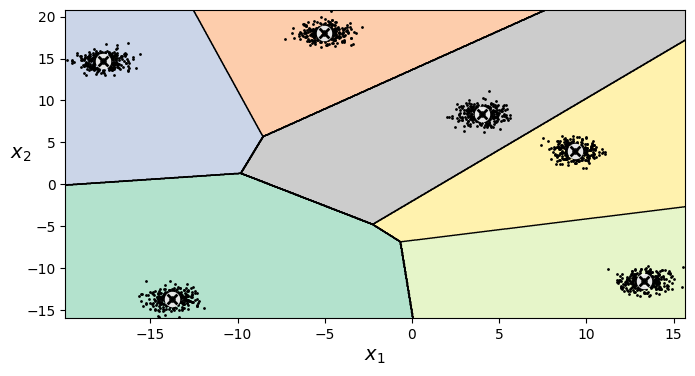

In [16]:
plt.figure(figsize=(8, 4))
plot_decision_boundaries(kmeans_rnd_10_inits, X)
plt.show()

### Método del codo y Silhouette Score

Cuando no conocemos el `k` óptimo, podemos calcular la inercia para distintos `k` (método del codo) y el silhouette score. Aquí adaptamos el rango para que vaya de 2 hasta 20 (el máximo permitido por la consigna).

In [17]:
from sklearn.metrics import silhouette_score

# Probamos K-Means con k desde 1 hasta 20 (el maximo de la consigna)
# Si quisieramos otro tope, basta con cambiar max_k
max_k = 20
kmeans_per_k = [KMeans(n_clusters=kk, random_state=42, n_init=10).fit(X) for kk in range(1, max_k + 1)]

# Inercia para el metodo del codo
inertias = [model.inertia_ for model in kmeans_per_k]

# Silhouette score (necesita al menos 2 clusters)
silhouette_scores = [silhouette_score(X, model.labels_) for model in kmeans_per_k[1:]]

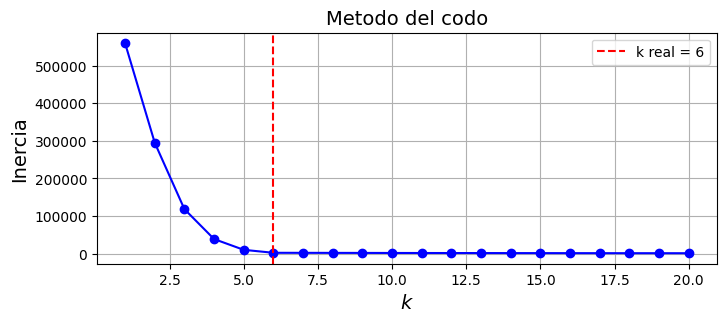

In [18]:
# Metodo del codo
plt.figure(figsize=(8, 3))
plt.plot(range(1, max_k + 1), inertias, "bo-")
plt.xlabel("$k$", fontsize=14)
plt.ylabel("Inercia", fontsize=14)
plt.title("Metodo del codo", fontsize=14)
plt.axvline(x=k, color="red", linestyle="--", label=f"k real = {k}")
plt.legend()
plt.grid(True)
plt.show()

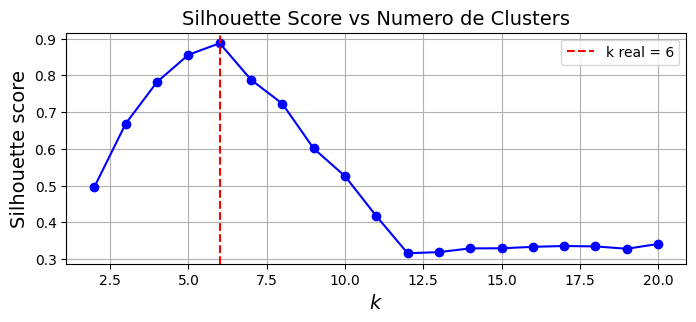

In [19]:
# Silhouette score para distintos k
ks = list(range(2, max_k + 1))

plt.figure(figsize=(8, 3))
plt.plot(ks, silhouette_scores, "bo-")
plt.xlabel("$k$", fontsize=14)
plt.ylabel("Silhouette score", fontsize=14)
plt.title("Silhouette Score vs Numero de Clusters", fontsize=14)
plt.axvline(x=k, color="red", linestyle="--", label=f"k real = {k}")
plt.legend()
plt.grid(True)
plt.show()

### Diagramas de silueta

Visualizamos los coeficientes de silueta agrupados por cluster para distintos valores de `k` cercanos al verdadero.

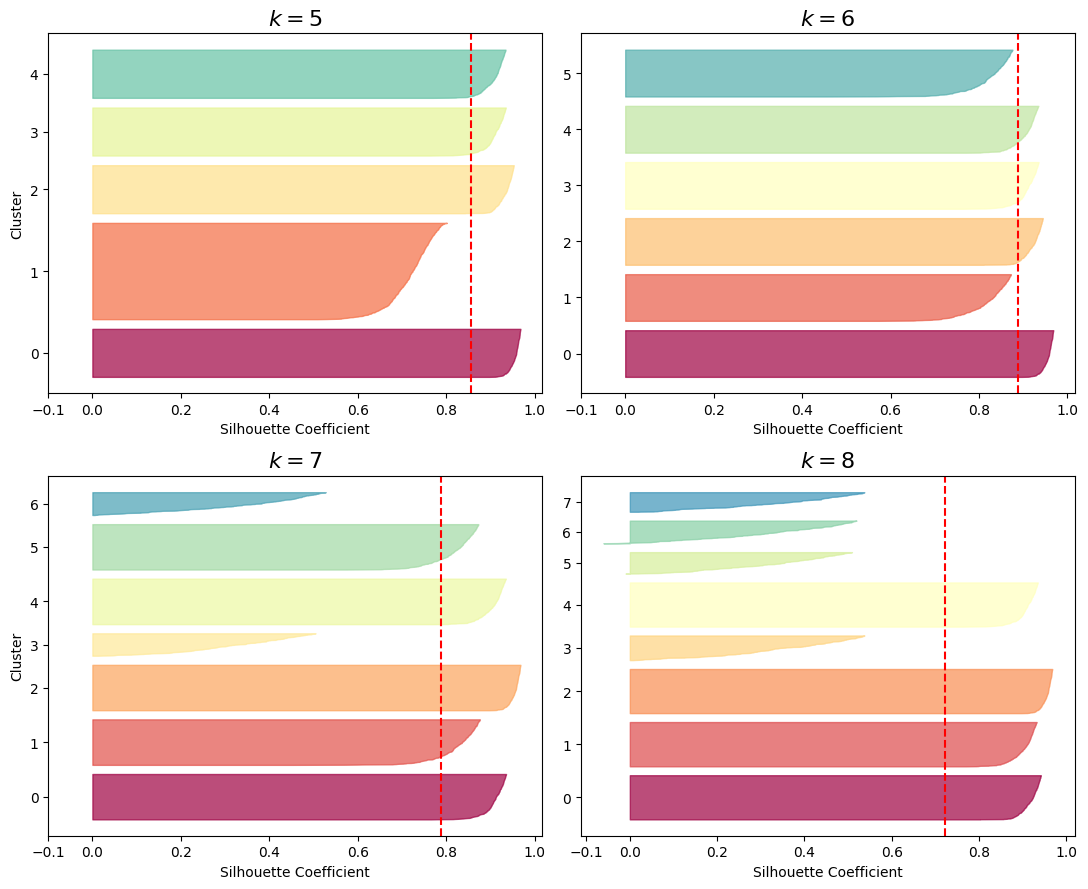

In [20]:
from sklearn.metrics import silhouette_samples
from matplotlib.ticker import FixedLocator, FixedFormatter
import matplotlib as mpl

plt.figure(figsize=(11, 9))

# Mostramos diagramas de silueta para 4 valores de k alrededor del valor real
ks_a_graficar = [max(2, k-1), k, k+1, k+2]
ks_a_graficar = [kk for kk in ks_a_graficar if kk <= max_k]

for plot_idx, kk in enumerate(ks_a_graficar):
    plt.subplot(2, 2, plot_idx + 1)

    y_pred_k = kmeans_per_k[kk - 1].labels_
    silhouette_coefficients = silhouette_samples(X, y_pred_k)

    padding = len(X) // 30
    pos = padding
    ticks = []
    for i in range(kk):
        coeffs = silhouette_coefficients[y_pred_k == i]
        coeffs.sort()

        color = mpl.cm.Spectral(i / kk)
        plt.fill_betweenx(np.arange(pos, pos + len(coeffs)), 0, coeffs,
                          facecolor=color, edgecolor=color, alpha=0.7)
        ticks.append(pos + len(coeffs) // 2)
        pos += len(coeffs) + padding

    plt.gca().yaxis.set_major_locator(FixedLocator(ticks))
    plt.gca().yaxis.set_major_formatter(FixedFormatter(range(kk)))
    if plot_idx % 2 == 0:
        plt.ylabel("Cluster")

    plt.gca().set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])
    plt.xlabel("Silhouette Coefficient")

    plt.axvline(x=silhouette_scores[kk - 2], color="red", linestyle="--")
    plt.title("$k={}$".format(kk), fontsize=16)

plt.tight_layout()
plt.show()

## Punto 2 - Aprendizaje semi-supervisado y activo con EMNIST

**Dataset elegido:** EMNIST (Extended MNIST) - variante Balanced

- 131.600 imagenes en escala de grises de 28x28 pixeles (n = 784 features).
- 47 clases balanceadas (mezcla de digitos 0-9, letras mayusculas y minusculas).
- Derivado del NIST Special Database 19, mismo formato que MNIST.
- Cumple los requisitos: n > 10 (tiene 784) y m > 10.000 (tiene 131.600).

Aplicamos el mismo flujo del cuadernillo original (que usaba MNIST) pero sobre caracteres manuscritos mas variados.

### Carga del dataset

Lo descargamos desde OpenML usando `fetch_openml`. EMNIST está publicado bajo distintos IDs; usamos el `data_id` para evitar ambigüedades.

In [21]:
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
import numpy as np

# Cargamos EMNIST desde OpenML.
# Usamos data_id = 41039 que corresponde a EMNIST_Balanced en OpenML
# (47 clases, 131.600 ejemplos, 28x28 = 784 pixeles).
# Si quisieramos otra variante (Letters, Digits, ByClass) habria que
# cambiar el data_id, pero esta es la version estandar disponible.
emnist = fetch_openml(data_id=41039, as_frame=True, parser='auto')
emnist.target = emnist.target.astype(np.int64)

print("Forma de los datos:", emnist.data.shape)
print("Forma de las etiquetas:", emnist.target.shape)
print("Numero de clases:", len(np.unique(emnist.target)))

Forma de los datos: (131600, 784)
Forma de las etiquetas: (131600,)
Numero de clases: 47


In [22]:
# Split train/test igual que en el cuadernillo original
X_train, X_test, y_train, y_test = train_test_split(
    emnist["data"], emnist["target"], random_state=42)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

X_train: (98700, 784)
X_test: (32900, 784)


### Aplicación de K-Means para encontrar imágenes representativas

Imaginamos que el dataset NO está etiquetado. Entrenamos K-Means con 50 grupos para encontrar las imágenes más representativas de cada cluster.

In [23]:
from sklearn.cluster import KMeans

# Numero de clusters. Lo dejamos en 50 igual al cuadernillo original.
# Si quisieramos cambiar el balance entre cantidad de etiquetas y precision,
# podemos subir o bajar este valor.
k = 50
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
X_digits_dist = kmeans.fit_transform(X_train)

In [24]:
# Forma de la matriz de distancias: una fila por muestra, una columna por cluster
print(X_digits_dist.shape)
print(X_digits_dist)

(98700, 50)
[[2220.80408872 2772.80205944 1868.99321845 ... 2825.11866731
  2255.0542134  2543.95513579]
 [2826.98909675 2571.0804766  2874.49879537 ... 3115.48000658
  2660.54625904 2909.18539324]
 [1902.29061502 2561.114092   2143.20357073 ... 2306.2575258
  2314.54164786 1888.48973513]
 ...
 [2314.04716861 2956.70791283 2584.58858595 ... 2518.8608923
  2768.16185561 2540.28710261]
 [2148.12530686 2346.19801897 1762.84507664 ... 2611.93039424
  2207.596809   2264.0806748 ]
 [1687.08504638 2337.26053571 1905.25814991 ... 2193.83960097
  2085.52457851 1855.53103295]]


In [25]:
# Para cada cluster, buscamos la muestra mas cercana al centroide
# (esa es la "imagen representativa" del cluster)
idxs = np.argmin(X_digits_dist, axis=0)
X_representative_digits = X_train.values[idxs]

In [26]:
print(X_representative_digits.shape)
print(X_representative_digits)

(50, 784)
[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]


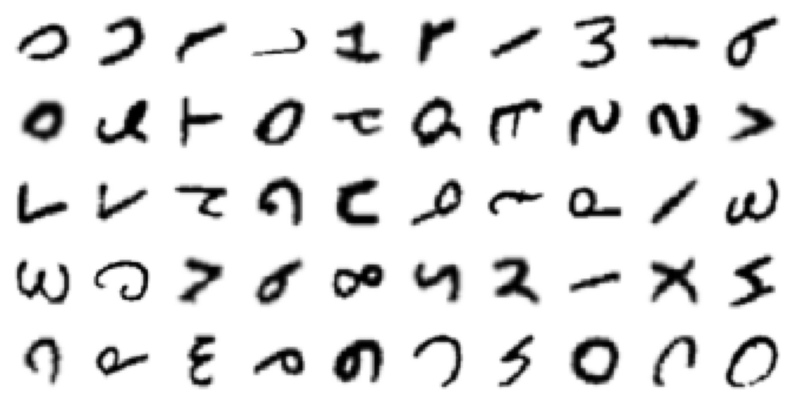

In [27]:
import matplotlib.pyplot as plt

# Visualizacion de las 50 imagenes representativas (una por cada cluster)
plt.figure(figsize=(10, 5))
for index, X_representative_digit in enumerate(X_representative_digits):
    plt.subplot(5, 10, index+1)
    plt.imshow(X_representative_digit.reshape(28, 28), cmap="binary")
    plt.axis('off')
plt.show()

El siguiente paso seria etiquetar manualmente esos 50 caracteres representativos. Como ya tenemos las etiquetas reales, las usamos directamente.

In [28]:
y_representative_digits = y_train.values[idxs]

### Entrenamiento del clasificador con las muestras representativas

Entrenamos una regresión logística usando solo las 50 imágenes representativas.

In [30]:
from sklearn.linear_model import LogisticRegression

# Regresion logistica entrenada con solo 50 muestras (las representativas)
log_reg2 = LogisticRegression(solver="lbfgs", max_iter=5000, random_state=42)
%time log_reg2.fit(X_representative_digits, y_representative_digits)
log_reg2.score(X_test, y_test)

c:\Users\erick\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1201: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  check_classification_targets(y)


CPU times: total: 562 ms
Wall time: 784 ms


c:\Users\erick\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


0.26285714285714284

Comparamos con entrenar usando 50 muestras aleatorias (sin selección por clustering).

In [31]:
# Mismo modelo pero con las primeras 50 muestras (sin la seleccion inteligente)
log_reg = LogisticRegression(solver="lbfgs", max_iter=5000, random_state=42)
%time log_reg.fit(X_train[:50], y_train[:50])
log_reg.score(X_test, y_test)

c:\Users\erick\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1201: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  check_classification_targets(y)


CPU times: total: 266 ms
Wall time: 426 ms


0.15370820668693008

La precisión con las muestras representativas debería ser claramente mejor que con muestras aleatorias. Esto demuestra que **calidad de los datos > cantidad**.

Ahora podemos propagar las etiquetas: a cada muestra del cluster le asignamos la etiqueta de su representante.

In [32]:
# Propagacion de etiquetas: cada muestra hereda la etiqueta del representante de su cluster
y_train_propagated = np.empty(len(X_train))
for i in range(k):
    y_train_propagated[kmeans.labels_ == i] = y_representative_digits[i]

In [33]:
# Entrenamos otra vez la regresion logistica usando 1000 muestras con etiquetas propagadas
log_reg3 = LogisticRegression(solver="lbfgs", max_iter=5000, random_state=42)
%time log_reg3.fit(X_train[:1000], y_train_propagated[:1000])
log_reg3.score(X_test, y_test)

CPU times: total: 35.5 s
Wall time: 3.75 s


0.2601215805471125

La propagación introduce algo de ruido (no todas las muestras del cluster son realmente de la misma clase). Para mejorar esto aplicamos **aprendizaje activo**.

### Aprendizaje activo

Identificamos las muestras donde el modelo está más inseguro (probabilidades más bajas) y las re-etiquetamos correctamente. Iteramos para mejorar.

In [34]:
# Predecimos probabilidades sobre las primeras 1000 muestras
probas = log_reg3.predict_proba(X_train[:1000])
labels_ixs = np.argmax(probas, axis=1)
labels = np.array([proba[ix] for proba, ix in zip(probas, labels_ixs)])

# Ordenamos por confianza ascendente: las primeras son las mas dudosas
sorted_ixs = np.argsort(labels)
labels[sorted_ixs[:10]]

array([0.9998758 , 0.99988497, 0.99988635, 0.99989043, 0.99989082,
       0.99989361, 0.99990043, 0.99990119, 0.99990563, 0.99990611])

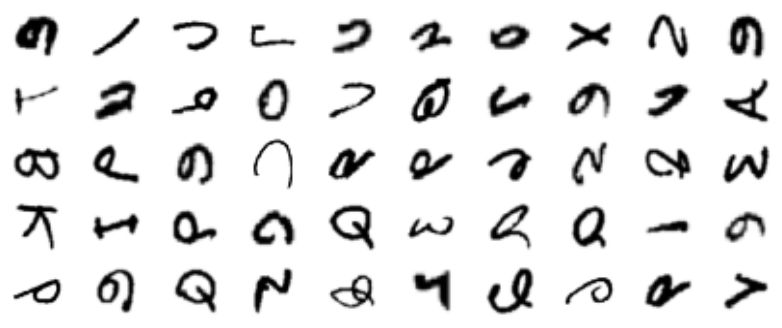

In [35]:
# Visualizacion de las k muestras de menor confianza (las mas confusas para el modelo)
X_lowest = X_train.values[:1000][sorted_ixs[:k]]
plt.figure(figsize=(10, 4))
for index, img in enumerate(X_lowest):
    plt.subplot(k // 10, 10, index + 1)
    plt.imshow(img.reshape(28, 28), cmap="binary", interpolation="bilinear")
    plt.axis('off')
plt.show()

In [36]:
# "Etiquetamos" estas muestras manualmente (aqui hacemos trampa con las labels reales)
y_lowest = y_train.values[:1000][sorted_ixs[:k]]
y_lowest

array([39,  1, 30,  7, 30, 44, 24, 33, 16, 39, 29, 30, 38, 24, 31, 11,  7,
       39, 31, 10, 11, 41, 39, 12,  9,  9,  6, 28, 40,  3, 20, 18,  9, 12,
       26,  3, 36, 36, 18, 39, 37, 39, 26,  5, 38, 35,  2, 16,  9, 31])

In [37]:
# Reemplazamos en el dataset propagado las etiquetas de las muestras que acabamos de corregir
y_train2 = y_train_propagated[:1000].copy()
y_train2[sorted_ixs[:k]] = y_lowest

In [38]:
# Entrenamos de nuevo el modelo con las etiquetas corregidas
log_reg5 = LogisticRegression(solver="lbfgs", max_iter=5000, random_state=42)
%time log_reg5.fit(X_train[:1000], y_train2)
log_reg5.score(X_test, y_test)

CPU times: total: 10.2 s
Wall time: 1.44 s


0.27379939209726445

Repitiendo este proceso varias veces (identificar muestras dudosas, corregirlas, reentrenar) iríamos mejorando la precisión hasta llegar a un nivel aceptable, etiquetando solo las muestras realmente útiles.

## Resumen

- **Punto 1:** generamos centroides aleatorios entre 1 y 20 con distancia mínima entre ellos, aplicamos K-Means y verificamos visualmente que recupera los grupos. Calculamos el método del codo y silhouette score para encontrar el `k` óptimo.
- **Punto 2:** sobre EMNIST Letters aplicamos aprendizaje semi-supervisado (etiquetando solo 50 muestras representativas) y aprendizaje activo (corrigiendo las muestras de menor confianza), demostrando que la calidad de las etiquetas pesa más que la cantidad.